In [77]:
from keras.datasets import imdb
import numpy as np
import matplotlib.pyplot as plt
from keras import Sequential
from keras.layers import Dense, SimpleRNN, Embedding, Flatten
from keras.utils import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.metrics import accuracy_score, confusion_matrix

In [53]:
(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=1000)

In [54]:
x_train.shape

(25000,)

In [55]:
x_train.shape[0]

25000

In [57]:
len(x_train[2])

141

In [58]:
x_train = pad_sequences(x_train,padding="post",maxlen=50)
x_test = pad_sequences(x_test,padding="post",maxlen=50)

In [59]:
x_train.shape

(25000, 50)

In [60]:
model = Sequential()

model.add(SimpleRNN(32, input_shape=(50,1), return_sequences=False))
model.add(Dense(1,activation='sigmoid'))

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

history = model.fit(x_train,y_train, epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8379 - loss: 0.3693 - val_accuracy: 0.7766 - val_loss: 0.5090
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8439 - loss: 0.3606 - val_accuracy: 0.7553 - val_loss: 0.5300
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8424 - loss: 0.3570 - val_accuracy: 0.7637 - val_loss: 0.5295
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8462 - loss: 0.3541 - val_accuracy: 0.7610 - val_loss: 0.5272
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8456 - loss: 0.3529 - val_accuracy: 0.7743 - val_loss: 0.5228


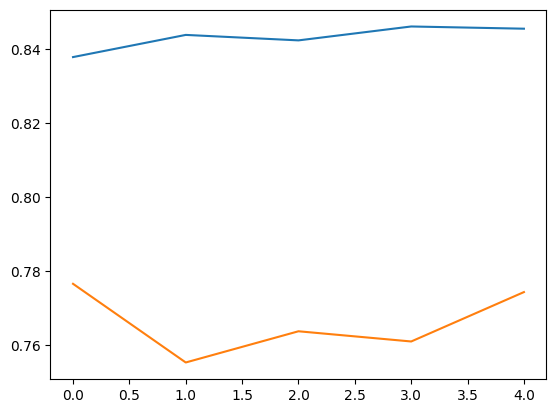

In [83]:
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')

RNN using Embedding

In [62]:
model = Sequential(
    [
        Embedding(input_dim=1000, output_dim=5, input_length=50),
        SimpleRNN(32,activation="tanh"),
        Dense(1,activation="sigmoid")
    ]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [80]:

model.compile(loss="binary_crossentropy",optimizer="adam",metrics=['accuracy'])
history = model.fit(x_train,y_train,epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8188 - loss: 0.4009 - val_accuracy: 0.7474 - val_loss: 0.5165
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8290 - loss: 0.3894 - val_accuracy: 0.7799 - val_loss: 0.4873
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8288 - loss: 0.3830 - val_accuracy: 0.7708 - val_loss: 0.4996
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8343 - loss: 0.3757 - val_accuracy: 0.7764 - val_loss: 0.4946
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.8376 - loss: 0.3727 - val_accuracy: 0.7724 - val_loss: 0.5029


In [84]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 5)          │         5,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,749 (73.24 KB)

 Trainable params: 6,249 (24.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12,500 (48.83 KB)

In [71]:
y_pred = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [72]:
y_pred

array([[0.30144885],
       [0.9365008 ],
       [0.2569838 ],
       ...,
       [0.1383263 ],
       [0.05402033],
       [0.75285786]], dtype=float32)

In [76]:
accuracy_score(y_test,(y_pred)>0.5)

0.77716

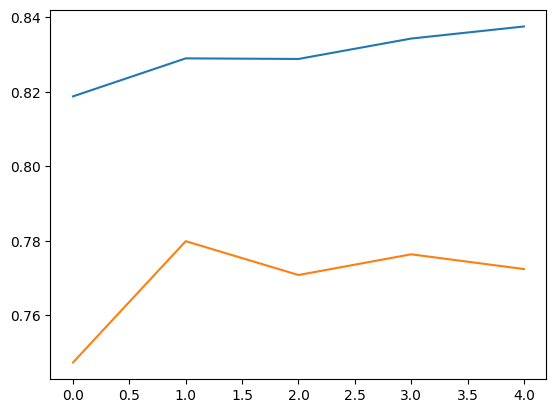

In [81]:
plt.plot(history.history['accuracy'],label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'],label = 'Validation Accuracy')


In [1]:
from google.colab import files
files.download("Sentiment_Analysis.ipynb")

FileNotFoundError: Cannot find file: Sentiment_Analysis.ipynb